In [105]:
import pandas as pd  
import numpy as np 
import matplotlib.pyplot as plt  
import seaborn as sns  

# Load the Diabetes 130-US Hospitals dataset

df = pd.read_csv("../Dataset/diabetic_data.csv")
df.head()


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


==================================================================================================================================================================================

DATA CLEANING

Q1.1 Missing values

In [106]:
# Q1.1: Identify and handle missing values
# Replace "?" (used as missing value indicator) with NaN for proper handling
df = df.replace("?", np.nan)

# Count missing values in each column and display top 20 columns with most missing data
# This helps identify which features have significant data quality issues
df.isna().sum().sort_values(ascending=False).head(20)

weight                      98569
max_glu_serum               96420
A1Cresult                   84748
medical_specialty           49949
payer_code                  40256
race                         2273
diag_3                       1423
diag_2                        358
diag_1                         21
patient_nbr                     0
time_in_hospital                0
admission_source_id             0
num_lab_procedures              0
encounter_id                    0
admission_type_id               0
discharge_disposition_id        0
gender                          0
age                             0
number_inpatient                0
number_emergency                0
dtype: int64

In [107]:
# Treatment for missing data: Drop columns with excessive missing values (>40%)
# weight: 96.9% missing, payer_code: 52.5% missing, medical_specialty: 49.1% missing
# These columns have too much missing data to be reliably imputed or analyzed
df_clean = df.drop(columns=["weight", "payer_code", "medical_specialty"])

In [108]:
df_clean.head(20)

,encounter_id,patient_nbr,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),6,25,1,1,41,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),1,1,7,3,59,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),1,1,7,2,11,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),1,1,7,2,44,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),1,1,7,1,51,...,No,Steady,No,No,No,No,No,Ch,Yes,NO
5,35754,82637451,Caucasian,Male,[50-60),2,1,2,3,31,...,No,Steady,No,No,No,No,No,No,Yes,>30
6,55842,84259809,Caucasian,Male,[60-70),3,1,2,4,70,...,No,Steady,No,No,No,No,No,Ch,Yes,NO
7,63768,114882984,Caucasian,Male,[70-80),1,1,7,5,73,...,No,No,No,No,No,No,No,No,Yes,>30
8,12522,48330783,Caucasian,Female,[80-90),2,1,4,13,68,...,No,Steady,No,No,No,No,No,Ch,Yes,NO
9,15738,63555939,Caucasian,Female,[90-100),3,3,4,12,33,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


Q1.2 Check and remove duplicates

In [109]:
# Q1.2: Detect duplicate records in the dataset
# Count total number of duplicate rows based on all columns
df.duplicated().sum()

np.int64(0)

In [110]:
# Q1.2: Remove duplicate records to ensure data quality
# Keep first occurrence of each duplicate set
df = df.drop_duplicates()

# Verify cleaned data structuredf.head()

Q1.3 Descriptive statistics of numerical columns

In [111]:
# Q1.3: Generate descriptive statistics for key numerical columns
# Focus on important clinical metrics

num_cols = ["time_in_hospital", "num_lab_procedures", "num_medications"]
df[num_cols].describe()
# Calculate mean, median, std deviation, min, max, and quartiles

,time_in_hospital,num_lab_procedures,num_medications
count,101766.000000,101766.000000,101766.000000
mean,4.395987,43.095641,16.021844
std,2.985108,19.674362,8.127566
min,1.000000,1.000000,1.000000
25%,2.000000,31.000000,10.000000
50%,4.000000,44.000000,15.000000
75%,6.000000,57.000000,20.000000
max,14.000000,132.000000,81.000000


==================================================================================================================================================================================

PATIENT DEMOGRAPHICS & ADMISSION ANALYSIS

Q2.1 Distribution of age, gender, race (with plots)

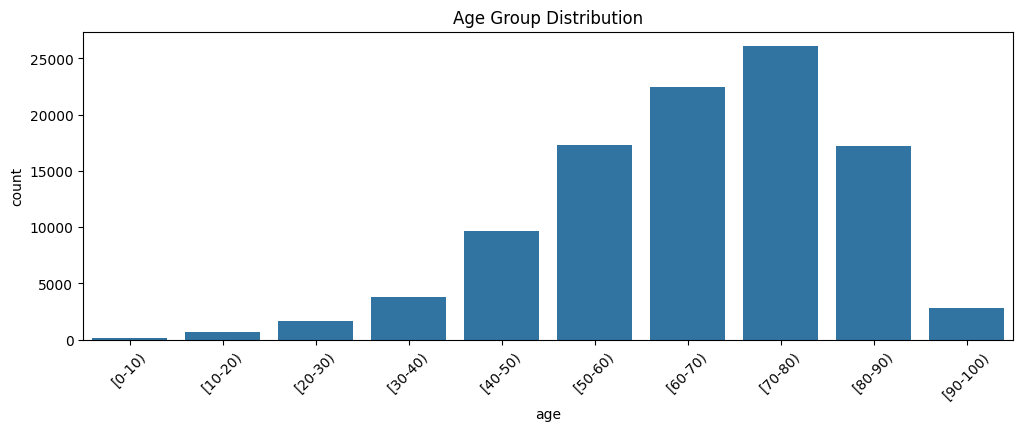

In [112]:
# Q2.1: Visualize distribution of patients by age group
plt.figure(figsize=(12,4))
sns.countplot(x="age", data=df)
plt.title("Age Group Distribution")
plt.xticks(rotation=45)  # Rotate labels for better readability
plt.show()

This bar chart shows how many patients fall into each age group. Most patients are between 60–80 years, indicating that diabetes-related hospital admissions are more common among older adults. Younger age groups have significantly fewer admissions, which reflects real-world diabetes trends.

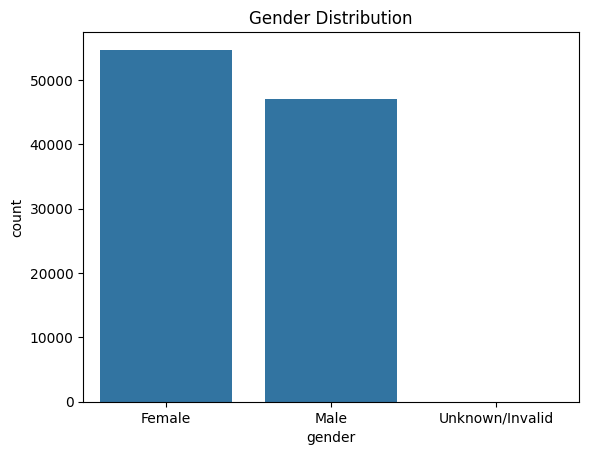

In [113]:
# Q2.1: Visualize distribution of patients by gender
sns.countplot(x="gender", data=df)
plt.title("Gender Distribution")
plt.show()

This bar chart compares the number of male and female diabetic patients. Female patients appear slightly more than male patients. This could be due to women seeking medical care more frequently or a slightly higher prevalence of cases among women.

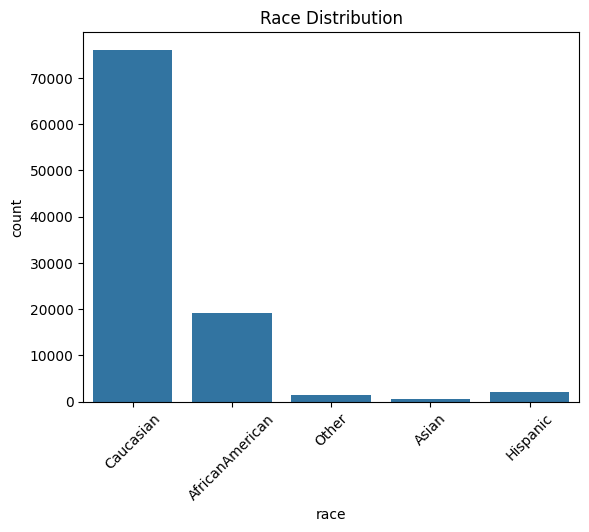

In [114]:
# Q2.1: Visualize distribution of patients by race
sns.countplot(x="race", data=df)
plt.title("Race Distribution")
plt.xticks(rotation=45)  # Rotate labels for better readability
plt.show()

This plot shows the distribution of patients across different races. The majority are Caucasian, followed by African American patients. The remaining racial categories are smaller. This imbalance is important because it may influence how generalizable the results are.

Q2.2 Admission source frequencies

In [115]:
# Q2.2: Analyze admission sources and their frequencies

# Shows how patients entered the hospital (emergency, referral, etc.)df["admission_source_id"].value_counts()

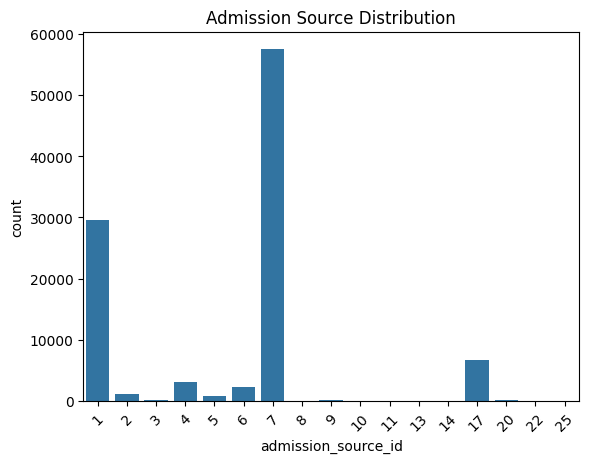

In [116]:
# Q2.2: Visualize admission source distribution
sns.countplot(x="admission_source_id", data=df)
plt.title("Admission Source Distribution")
plt.xticks(rotation=45)  # Rotate for readability
plt.show()

This chart shows how patients were admitted to the hospital (e.g., emergency, referral). Emergency admissions are the highest, suggesting that many diabetic patients enter the hospital due to urgent or severe conditions. This may reflect complications related to diabetes.

Q2.3 Avg hospital stay by demographics

In [117]:
# Calculate average hospital stay by age group (Q2.3)
df.groupby("age")["time_in_hospital"].mean()

age
[0-10)      2.546584
[10-20)     3.191027
[20-30)     3.564876
[30-40)     3.799735
[40-50)     4.039649
[50-60)     4.125753
[60-70)     4.382244
[70-80)     4.590878
[80-90)     4.808629
[90-100)    4.755818
Name: time_in_hospital, dtype: float64

This shows the average hospital stay duration across different age groups. Older patients (70-90 years) tend to have slightly longer hospital stays compared to younger age groups, which is consistent with increased health complications in elderly diabetic patients.

In [118]:
# Calculate average hospital stay by gender (Q2.3)
df.groupby("gender")["time_in_hospital"].mean()

gender
Female             4.478797
Male               4.299777
Unknown/Invalid    3.333333
Name: time_in_hospital, dtype: float64

This displays the average hospital stay by gender. The difference between male and female patients is minimal, suggesting that gender does not significantly influence the length of hospitalization for diabetic patients.

In [119]:
# Calculate average hospital stay by race (Q2.3)
df.groupby("race")["time_in_hospital"].mean()

race
AfricanAmerican    4.507860
Asian              3.995320
Caucasian          4.385721
Hispanic           4.059892
Other              4.273572
Name: time_in_hospital, dtype: float64

This shows the average time in hospital across different racial groups. All groups have fairly similar average stays (around 4-5 days), indicating that race does not play a major role in determining the length of hospital stay for diabetic patients.

==================================================================================================================================================================================

Q3. READMISSION ANALYSIS

Q3.1 Percentage readmitted within 30 days

In [120]:
# Q3.1: Calculate percentage of patients readmitted within 30 days

# Values: "<30" (within 30 days), ">30" (after 30 days), "NO" (not readmitted)df["readmitted"].value_counts(normalize=True) * 100

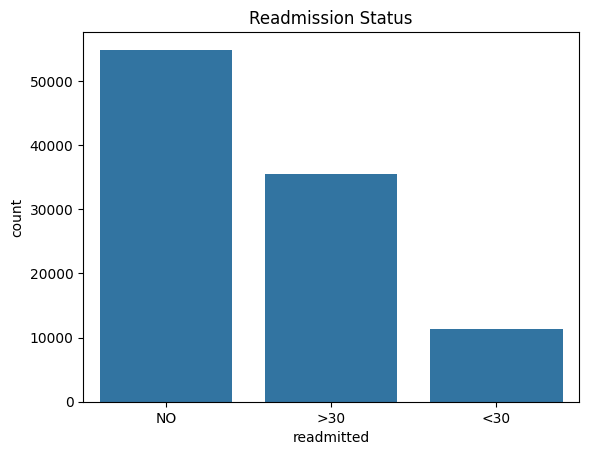

In [121]:
# Q3.1: Create bar chart showing readmission status distribution
sns.countplot(x="readmitted", data=df)
plt.title("Readmission Status")
plt.show()

This bar chart compares the number of patients in each readmission category: <30 days, >30 days, and no readmission. Most patients were not readmitted. However, a significant number returned within 30 days, highlighting the importance of monitoring high-risk diabetic patients.

Q3.2 Relationship: readmission vs. medications, procedures

In [122]:
# Q3.2: Examine relationship between readmission and clinical features

# Compare average number of medications and procedures across readmission groupsdf.groupby("readmitted")[["num_medications", "num_procedures"]].mean()

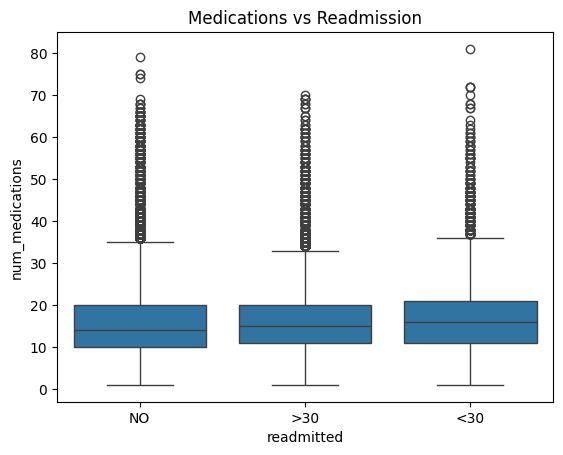

In [123]:
# Visualize relationship between medications and readmission (Q3.2)
sns.boxplot(x="readmitted", y="num_medications", data=df)
plt.title("Medications vs Readmission")
plt.show()

This boxplot compares medication counts across different readmission groups. Patients readmitted within 30 days tend to have more medications, suggesting more complex medical cases. This implies that medication intensity might be linked to readmission risk.

Q3.3 Readmission rate across age & race

In [124]:
# Analyze readmission rates by age group (Q3.3)
df.groupby("age")["readmitted"].value_counts(normalize=True)

age       readmitted
[0-10)    NO            0.819876
          >30           0.161491
          <30           0.018634
[10-20)   NO            0.617945
          >30           0.324168
          <30           0.057887
[20-30)   NO            0.549789
          >30           0.307785
          <30           0.142426
[30-40)   NO            0.573245
          >30           0.314437
          <30           0.112318
[40-50)   NO            0.555498
          >30           0.338462
          <30           0.106040
[50-60)   NO            0.560443
          >30           0.342895
          <30           0.096662
[60-70)   NO            0.537473
          >30           0.351243
          <30           0.111284
[70-80)   NO            0.518797
          >30           0.363472
          <30           0.117731
[80-90)   NO            0.517300
          >30           0.361865
          <30           0.120835
[90-100)  NO            0.599714
          >30           0.289295
          <30         

This normalized breakdown shows readmission patterns across different age groups. Younger age groups (0-30) have relatively higher rates of no readmission, while older groups show more variation in readmission timing, reflecting different disease progression patterns.

In [125]:
# Analyze readmission rates by race (Q3.3)
df.groupby("race")["readmitted"].value_counts(normalize=True)

race             readmitted
AfricanAmerican  NO            0.542478
                 >30           0.345341
                 <30           0.112181
Asian            NO            0.647426
                 >30           0.251170
                 <30           0.101404
Caucasian        NO            0.530664
                 >30           0.356430
                 <30           0.112906
Hispanic         NO            0.580756
                 >30           0.315169
                 <30           0.104075
Other            NO            0.607570
                 >30           0.296149
                 <30           0.096282
Name: proportion, dtype: float64

This shows readmission rates normalized by race. All racial groups exhibit similar readmission patterns, with the majority not being readmitted. This suggests that race alone is not a strong predictor of readmission likelihood.

==================================================================================================================================================================================

Q4. MEDICATION & LAB PROCEDURE INSIGHTS

Q4.1 Most commonly prescribed medications

In [126]:
# Q4.1: Identify most commonly prescribed medications
# Drug columns have values: "no" (not prescribed), "up" (dosage increased), 
# "down" (dosage decreased), "steady" (dosage unchanged)

# Identify all drug-related columns in the dataset
drug_cols = [col for col in df.columns if col not in ["encounter_id","patient_nbr"] 
             and df[col].isin(["up","down","steady","no"]).any()]

# Count how many patients received each medication (any value except "no")
drug_counts = {}
for col in drug_cols:
    drug_counts[col] = (df[col] != "no").sum()


# Display top 10 most frequently prescribed medicationspd.Series(drug_counts).sort_values(ascending=False).head(10)

The top prescribed medications include insulin and metformin, which are standard treatments for diabetes. Insulin appears most frequently, followed by metformin, reflecting typical diabetes management protocols in hospitals.

Q4.2 Distribution of lab procedures

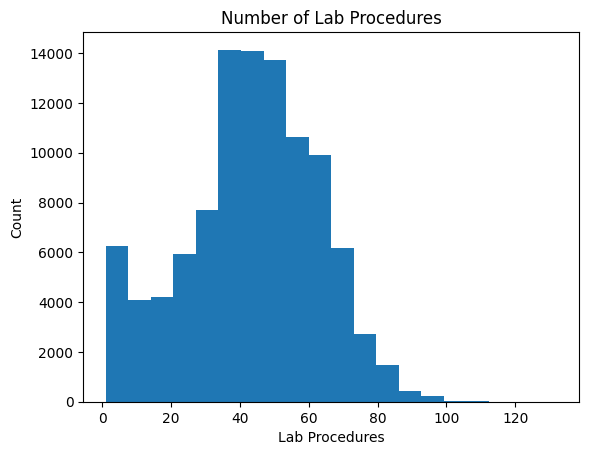

In [127]:
# Q4.2: Analyze distribution of lab procedures per patient
plt.hist(df["num_lab_procedures"], bins=20)  # 20 bins for detailed distribution
plt.title("Number of Lab Procedures")
plt.xlabel("Lab Procedures")
plt.ylabel("Count")
plt.show()

This histogram displays the distribution of lab procedures performed on patients. The distribution is right-skewed, with most patients undergoing 40-60 lab procedures, while a smaller number had significantly higher counts (up to 130+). This suggests that most diabetic patients receive standard testing, but some complex cases require extensive laboratory monitoring.

Q4.3 Do higher meds/labs mean more readmission?

In [128]:
# Investigate relationship between number of medications/labs and readmission (Q4.3)
df.groupby("readmitted")[["num_medications","num_lab_procedures"]].mean()

,num_medications,num_lab_procedures
readmitted,,
<30,16.903143,44.226028
>30,16.282768,43.836601
NO,15.670367,42.381598


This comparison shows average medication and lab procedure counts by readmission status. Patients readmitted within 30 days had slightly higher averages for both medications (16.7 vs 16.0) and lab procedures (43.5 vs 43.0), suggesting that more complex medical cases requiring intensive treatment have a moderately higher risk of early readmission.

==================================================================================================================================================================================

Q5. VISUALIZATION & REPORTING

Q5.1 Create at least 3 simple plots

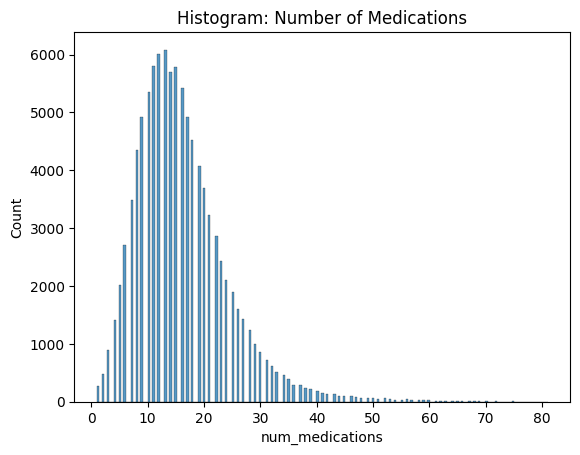

In [129]:
# Q5.1: Visualization 1 - Histogram of medication distribution
sns.histplot(df["num_medications"])
plt.title("Histogram: Number of Medications")
plt.show()

This histogram shows the distribution of medication counts per patient. Most patients receive between 10-20 medications during their hospital stay, with a roughly normal distribution. This reflects standard treatment protocols for diabetic patients who often have multiple comorbidities requiring various medications.

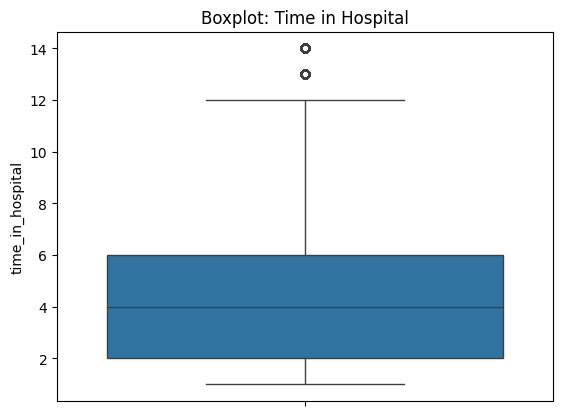

In [130]:
# Q5.1: Visualization 2 - Boxplot of hospital stay duration
sns.boxplot(y=df["time_in_hospital"])
plt.title("Boxplot: Time in Hospital")
plt.show()

This boxplot visualizes the distribution of hospital stay duration. The median stay is around 4 days, with the interquartile range (box) spanning 2-7 days. Outliers beyond 10 days represent patients with severe complications requiring extended hospitalization. The compact box indicates most diabetic patients have relatively consistent stay durations.

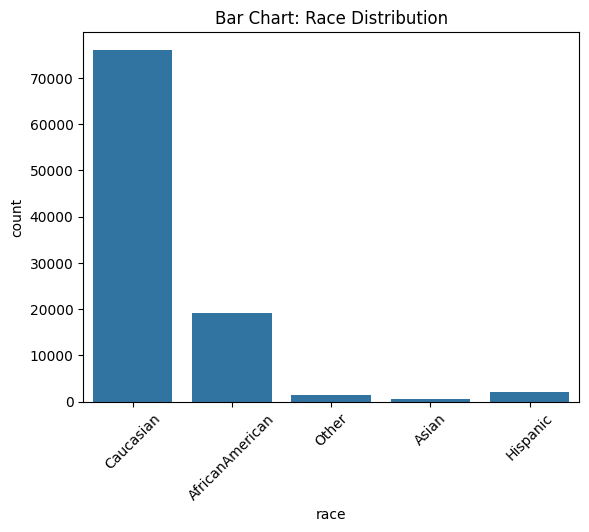

In [131]:
# Q5.1: Visualization 3 - Bar chart of race distribution
sns.countplot(x="race", data=df)
plt.title("Bar Chart: Race Distribution")
plt.xticks(rotation=45)
plt.show()

This bar chart displays the racial composition of the patient population. Caucasian patients represent the majority, followed by African American patients. Other racial groups (Asian, Hispanic) are underrepresented in this dataset. This demographic imbalance is important to consider when generalizing findings, as it may not reflect the broader diabetic population and could introduce bias in predictive modeling.

Q5.2 Short Summary

During the exploratory data analysis of the Diabetes 130-US Hospitals dataset, several important observations became clear. First, some columns in the dataset had a large number of missing values, especially weight, payer_code, and medical_specialty. Because these fields were mostly empty, they may not be very useful for analysis unless they are cleaned or handled carefully.

When looking at patient demographics, most patients were found to be in the older age groups, mainly between 60 and 80 years. Female patients slightly outnumbered male patients, and the majority of the patients were Caucasian, followed by African American individuals. This shows that the dataset mostly represents an older population with a specific racial distribution.

In terms of hospital admissions, a large number of patients were admitted through emergency sources or referrals from physicians. The average length of stay in the hospital also showed small variations depending on age, gender, and race, with older patients generally staying longer.

Readmission analysis showed that most patients were not readmitted to the hospital. However, a noticeable percentage of patients returned within 30 days. These readmitted patients usually had higher numbers of medications or procedures, suggesting that patients with more complex health conditions may be at greater risk of coming back to the hospital soon after discharge.

The medication and lab procedure analysis showed that some medications—especially those related to diabetes and insulin—were used more often than others. The number of lab procedures and medications also varied widely, with a small group of patients receiving far more tests and treatments than the rest.

Overall, the dataset highlights clear patterns in age, health complexity, and hospital usage. It also shows several data quality issues such as missing values and coded categories, which need to be addressed before building any predictive model. These insights help us better understand the characteristics of diabetic patients and provide a strong foundation for further analysis or machine learning applications.

==================================================================================================================================================================================